# Set Up

In [ ]:
# load packages
import pandas as pd
import numpy as np
import nibabel as nib
from nilearn import surface
from nilearn import image
import os
import json
from scipy.stats import pearsonr, ttest_ind, spearmanr
import pingouin as pg
import seaborn as sns
import matplotlib.pyplot as plt
import subprocess

from utils import annotate_regression_corr_bayes

In [ ]:
#flag to save files
save_CSVs=False
save_maps=False

# define paths
project_dir = os.chdir('..')
fig_dir = f'{project_dir}figures/'
data_dir = f'{project_dir}data/'
fs_dir = f'{data_dir}freesurfer/'

#define sub list
groups = pd.read_csv(f'{data_dir}DFs/groups.csv')
subs = list(groups['sub'])

#define variables
my_bundles = ['Left Arcuate','Left Posterior Arcuate',
              'Left Inferior Longitudinal',
              'Left Posterior Vertical Occipital','Left Anterior Vertical Occipital',
              'Left Inferior Fronto-occipital']

hemis = ['LH']
ROIs = ['VWFA1','VWFA2']


# Project Density Maps to Surface

In [18]:
for hemi in hemis:
    for sub in subs:
        wm_density_path = f'{data_dir}pyAFQ_3.3/{sub}/{sub}_desc-density_tractography'


        #check that the sub has wm density data before continuing
        if os.path.exists(f'{wm_density_path}.nii.gz'):
            
            # load surf mesh and density map data
            mesh = surface.load_surf_mesh(f'{fs_dir}{sub}/surf/{hemi.lower()}.white')
            wm_img = nib.load(f'{wm_density_path}.nii.gz')
            bundles = json.load(open(f'{wm_density_path}.json'))['bundles']

            #grab indices of speficied bundles
            bundle_indices = np.where(np.isin(bundles, my_bundles))[0]
            
            #loop through specified bundles
            for indx in bundle_indices:
                bundle_img = image.index_img(wm_img,indx)
                surf_wm_img = surface.vol_to_surf(bundle_img,mesh)
                
                # save wm density surface imgs 
                if save_maps:
                    #create map object
                    gifti=nib.gifti.GiftiImage(darrays=[nib.gifti.GiftiDataArray(surf_wm_img.astype(np.float32))])#requires float32
                    
                    #create save_path
                    save_path = f'{project_dir}data/surf_density_maps/{sub}/'
                    if not os.path.exists (save_path):
                        os.makedirs(save_path)
                    
                    #save the maps
                    nib.save(gifti,f'{save_path}{sub}_{bundles[indx]}_{hemi}.gii')
                    
            print(sub) #progress check for sanity

sub-1
sub-2
sub-3
sub-4
sub-5
sub-6
sub-7
sub-9
sub-10
sub-11
sub-12
sub-13
sub-14
sub-15
sub-16
sub-17
sub-18
sub-19
sub-20
sub-21
sub-22
sub-23
sub-24
sub-25
sub-26
sub-27
sub-29
sub-30
sub-32
sub-33
sub-34
sub-35
sub-36
sub-37
sub-38
sub-39
sub-40
sub-41
sub-42
sub-43
sub-44
sub-45
sub-46
sub-47
sub-48
sub-49
sub-50
sub-51
sub-52
sub-53
sub-54
sub-55
sub-56
sub-57
sub-58
sub-59
sub-60
sub-61
sub-62
sub-63
sub-64
sub-65
sub-67
sub-68
sub-69
sub-71
sub-72
sub-73
sub-74
sub-75
sub-76
sub-77
sub-78
sub-79
sub-80
sub-81
sub-83
sub-84
sub-85
sub-86
sub-87
sub-88
sub-89
sub-90


# Extract Mean Bundle Desnities

In [36]:
# set up environment to use FreeSurfee commands to apply smoothing
#set FreeSurfer paths from your environment
# FREESURFER_HOME = '/share/software/user/open/freesurfer/7.3.2'
# GROUP_HOME = '/home/groups/jyeatman'
# SUBJECTS_DIR = '/oak/stanford/groups/jyeatman/LMB_Stanford/LMB_BIDS/derivatives/freesurfer/'

data = []

#loop through hemis, subs, session, and bundles
for hemi in hemis:
    for sub in subs:
        for bundle in my_bundles:
            #check in bundle density maps exists before continuing
            surf_dens_path = f'{data_dir}surf_density_maps/{sub}/{sub}_{bundle}_{hemi}.gii'
            if os.path.exists(surf_dens_path):

                #load density map
                surf_dens_map = surface.load_surf_data(surf_dens_path)

                #loop through rois to extract mean values
                for roi in ROIs:
                    #check that roi exists before continuing
                    label_path = f'{fs_dir}{sub}/label/{sub}_T-v-ALL_{roi}_{hemi}.label'
                    if os.path.exists(label_path):
                        #load label
                        label = surface.load_surf_data(label_path)

                        #calculate mean bundle streamline density
                        roi_bundle_density = np.mean(surf_dens_map[label])

                        #append data to data list
                        data.append({
                            'sub': sub,
                            'hemi': hemi,
                            'roi': roi,
                            'bundle': bundle,
                            'bundle_density': roi_bundle_density
                        })

        print(sub)

# Create dataframe
df = pd.DataFrame(data)

# Load and merge with group & score data
df_groups = pd.read_csv(f'{data_dir}DFs/groups.csv')
df = pd.merge(df, df_groups, how='left', on='sub')
df_scores = pd.read_csv(f'{data_dir}DFs/wj_scores.csv')
df = pd.merge(df, df_scores, how='left', on='sub')

if save_CSVs:
    df.to_csv(f'{data_dir}DFs/wm_density.csv', index=False)

sub-1
sub-2
sub-3
sub-4
sub-5
sub-6
sub-7
sub-9
sub-10
sub-11
sub-12
sub-13
sub-14
sub-15
sub-16
sub-17
sub-18
sub-19
sub-20
sub-21
sub-22
sub-23
sub-24
sub-25
sub-26
sub-27
sub-29
sub-30
sub-32
sub-33
sub-34
sub-35
sub-36
sub-37
sub-38
sub-39
sub-40
sub-41
sub-42
sub-43
sub-44
sub-45
sub-46
sub-47
sub-48
sub-49
sub-50
sub-51
sub-52
sub-53
sub-54
sub-55
sub-56
sub-57
sub-58
sub-59
sub-60
sub-61
sub-62
sub-63
sub-64
sub-65
sub-67
sub-68
sub-69
sub-71
sub-72
sub-73
sub-74
sub-75
sub-76
sub-77
sub-78
sub-79
sub-80
sub-81
sub-83
sub-84
sub-85
sub-86
sub-87
sub-88
sub-89
sub-90


# Plot & Analyze


VWFA1
Left Arcuate
dys: 0.878 ± 3.106
typ: 0.635 ± 2.450
t(54.531)=0.332 (p=0.7415; CI=(-1.222, 1.706)
-1.222     1.706     54.531
Left Posterior Arcuate
dys: 0.271 ± 1.294
typ: 0.179 ± 0.681
t(58.242)=0.358 (p=0.7220; CI=(-0.423, 0.608)
-0.423     0.608     58.242
Left Inferior Longitudinal
dys: 3.101 ± 7.832
typ: 1.171 ± 1.577
t(41.893)=1.451 (p=0.1543; CI=(-0.755, 4.616)
-0.755     4.616     41.893
Left Posterior Vertical Occipital
dys: 3.766 ± 6.810
typ: 4.531 ± 6.154
t(49.955)=-0.443 (p=0.6593; CI=(-4.229, 2.700)
-4.229     2.700     49.955
Left Anterior Vertical Occipital
dys: 4.869 ± 7.694
typ: 7.804 ± 8.603
t(42.222)=-1.317 (p=0.1948; CI=(-7.431, 1.561)
-7.431     1.561     42.222
Left Inferior Fronto-occipital
dys: 1.673 ± 3.892
typ: 1.259 ± 2.193
t(58.846)=0.523 (p=0.6030; CI=(-1.171, 2.000)
-1.171     2.000     58.846

VWFA2
Left Arcuate
dys: 7.717 ± 10.692
typ: 6.796 ± 9.453
t(48.611)=0.331 (p=0.7417; CI=(-4.664, 6.505)
-4.664     6.505     48.611
Left Posterior Arcuate
dy

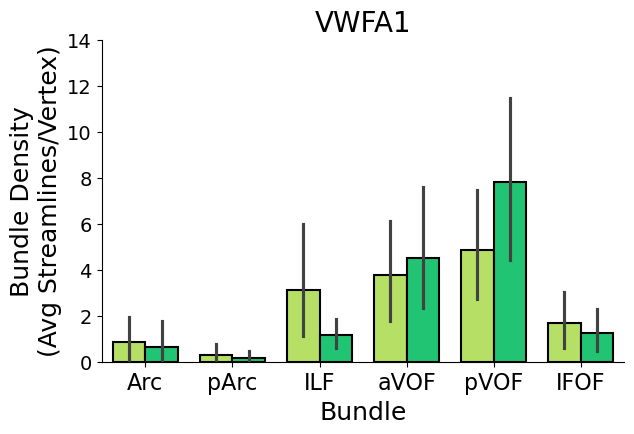

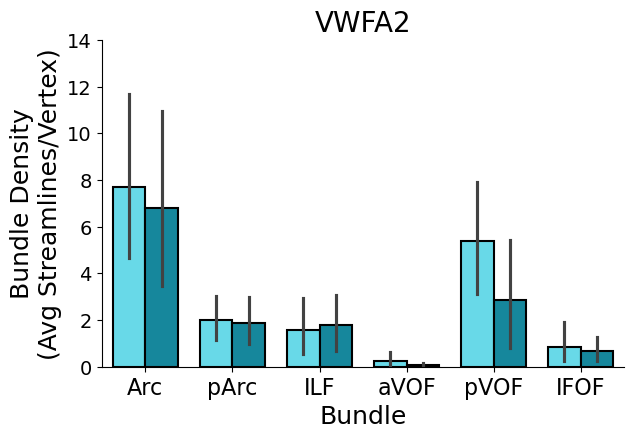

In [ ]:
# Set to True if you want to save the figure
save_fig = False

#read in and filter data
df = pd.read_csv(f'{data_dir}DFs/wm_density.csv').query('hemi=="LH"')

# set color palette
# Define your color palettes for each ROI
dysGroup_palette_VWFA1 = {'dys': '#BBF451', 'typ': '#05DF72'}
dysGroup_palette_VWFA2 = {'dys': '#53EAFD', 'typ': '#0097b2'} 

# ROI labels and legend labels
legend_labels = ['Dyslexic', 'Typical']

bundle_titles = {'Left Arcuate': "Arc",
                 'Left Posterior Arcuate': 'pArc',
                 'Left Inferior Longitudinal': 'ILF',
                 'Left Anterior Vertical Occipital': 'aVOF',
                 'Left Posterior Vertical Occipital': 'pVOF',
                 'Left Inferior Fronto-occipital': 'IFOF'}

for roi in ROIs:
    print(f'\n{roi}')
    
    # Select palette based on ROI
    if roi == 'VWFA1':
        current_palette = dysGroup_palette_VWFA1
    elif roi == 'VWFA2':
        current_palette = dysGroup_palette_VWFA2
    
    # Get sizes for each ROI and group
    roi_df = df.query('roi==@roi')
    dys_df = roi_df.query('dys_group=="dys"')
    typ_df = roi_df.query('dys_group=="typ"')
    
    # Calculate p-values for significance using t-tests
    p_values = []
    t_values=[]
    DOFs=[]
    CIs=[]
    avg_sizes=[]
    for bundle in my_bundles:

        # run test
        results = ttest_ind(dys_df.query('bundle==@bundle')['bundle_density'],
                                  typ_df.query('bundle==@bundle')['bundle_density'],
                                  equal_var=False)

        # grab results
        t = results.statistic
        p = results.pvalue
        DOF = results.df
        CI = results.confidence_interval()

        #append results
        t_values.append(t)
        p_values.append(p)
        DOFs.append(DOF)
        CIs.append(CI)

        #Calculate bayes factor
        bf10 = pg.bayesfactor_ttest(
            t=t,
            nx=len(dys_df.query('bundle==@bundle')['bundle_density']),
            ny=len(typ_df.query('bundle==@bundle')['bundle_density']),
            paired=False,
            alternative='two-sided',
            r=0.707
        )
        bf01 = 1 / bf10

        print(bundle)
        print(f'dys: {np.mean(dys_df.query("bundle==@bundle")["bundle_density"]):.3f} ± {np.std(dys_df.query("bundle==@bundle")["bundle_density"]):.3f}')
        print(f'typ: {np.mean(typ_df.query("bundle==@bundle")["bundle_density"]):.3f} ± {np.std(typ_df.query("bundle==@bundle")["bundle_density"]):.3f}')
        print(f't({DOF:.3f})={t:.3f} (p={p:.4f}; CI=({CI.low:.3f}, {CI.high:.3f})')
        print(f'{CI.low:.3f}     {CI.high:.3f}     {DOF:.3f}')
        print(f'bf01 = {bf01:.3f}\n\n')

    # Plot the data
    g = sns.catplot(x='bundle', y='bundle_density', hue='dys_group', hue_order=['dys', 'typ'],
                    data=roi_df, kind='bar', palette=list(current_palette.values()),
                    height=4, aspect=1.5,width=0.75,)
    
    #set plot aesthetics
    g.set_axis_labels("Bundle", f"Bundle Density\n(Avg Streamlines/Vertex)", size=18)
    g.set_yticklabels(size=14)
    g.set_xticklabels([bundle_titles[bundle] for bundle in list(bundle_titles.keys())],size=16)
#     plt.yticks(np.arange(0, 10, 1))
    plt.title(roi,size=20)
#     plt.ylim(0,9)
    


    # Add borders to the boxes
    for ax in g.axes.flat:
        for box in ax.patches:
            box.set_edgecolor('black')  
            box.set_linewidth(1.5)      

    # Remove the original legend
    g._legend.remove()

    # Add significance indicators
    for i, p in enumerate(p_values):
        significance = ''
        if pd.notna(p):
            if p < 0.001:
                significance = '***'
            elif p < 0.01:
                significance = '**'
            elif p < 0.05:
                significance = '*'
            elif p >= 0.05:
                significance = ''
        if significance:
            # Position the text above the highest box for the given ROI
            y_max = 3
            if np.isfinite(y_max):  
                ax = g.axes.flat[0]
                ax.text(i, y_max + 0.1, significance, ha='center', va='bottom', fontsize=20, color='black')

    # Save the figure
    if save_fig:
        plt.savefig(f'{fig_dir}{roi}_wm-dens_bar.png', bbox_inches="tight", dpi=400)

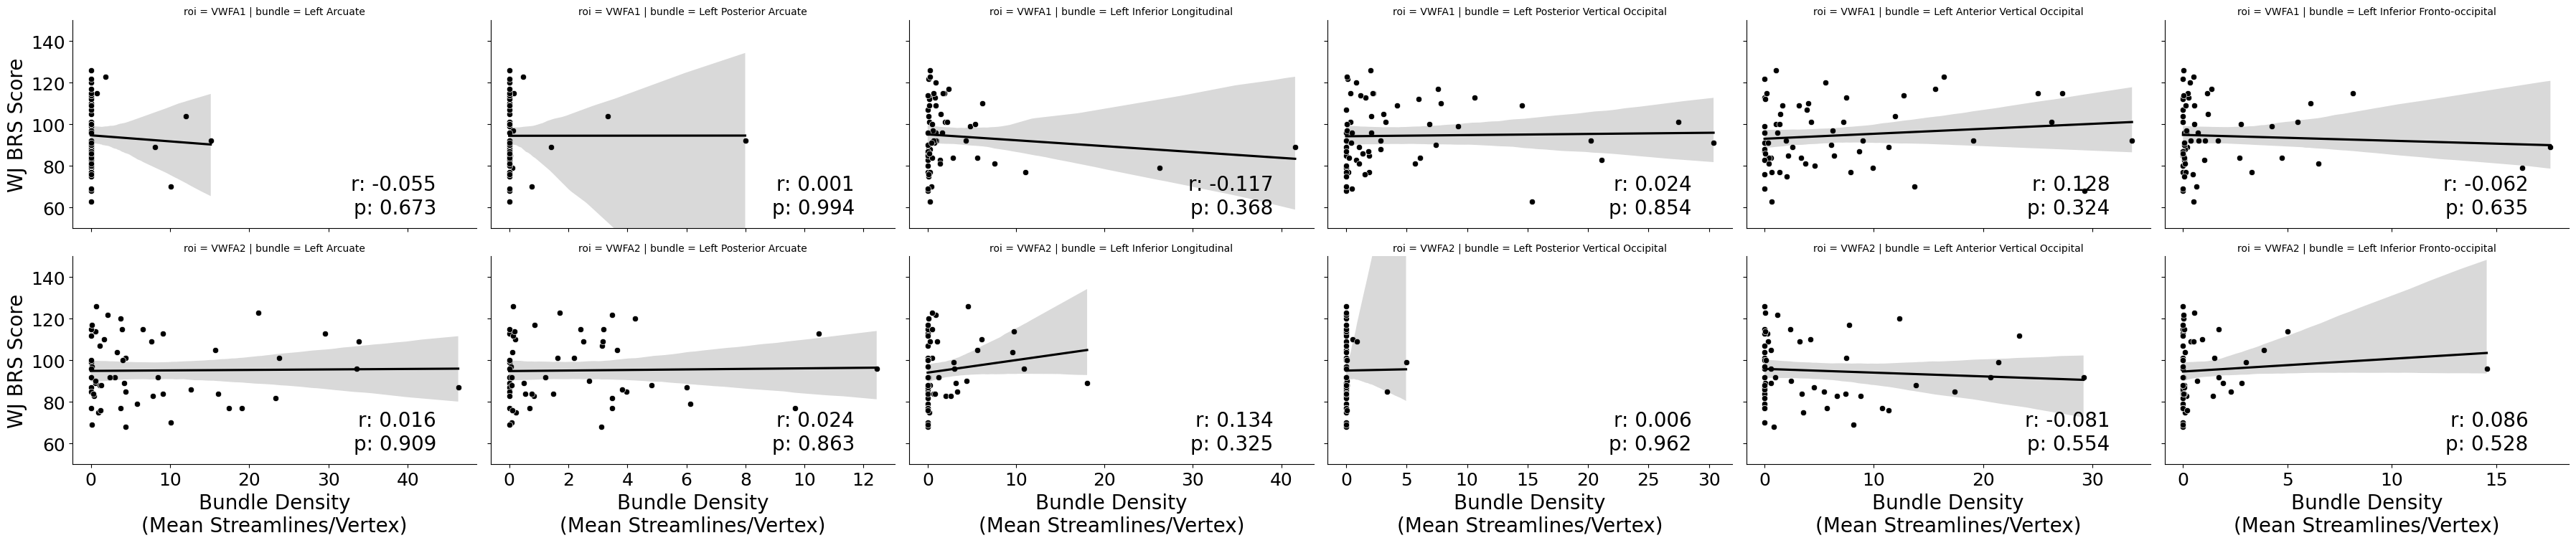

In [ ]:
# Set to True if you want to save the figure
save_fig = True

#read in and filter data
df = pd.read_csv(f'{data_dir}DFs/wm_density.csv').query('hemi=="LH"')
df = df.query('roi=="VWFA1" or roi=="VWFA2"')

dysGroup_palette = {
    'dys': '#8E44AD',
    'typ': '#BB8FCE'}

#define variables
assessments = ['wj_brs']
rois = ['VWFA1','VWFA2']


# Create a FacetGrid
g = sns.FacetGrid(df, row='roi', col='bundle', 
                  height=4, 
                  aspect=1.5, 
                  palette=list(dysGroup_palette.values()),
                 sharex='col')

# Map the scatterplot and regplot onto the FacetGrid
g.map(sns.scatterplot, 'bundle_density', 'wj_brs', color='black')
g.map(sns.regplot, 'bundle_density', 'wj_brs', scatter=False, color='black')

# Apply the annotation function to each subplot
g.map_dataframe(annotate_regression_corr_bayes,x_param='bundle_density',y_param='wj_brs')

# Set uniform x and y-axis labels
g.set_axis_labels('Bundle Density\n(Mean Streamlines/Vertex)', 'WJ BRS Score', size=20)

# Set ylimit for better visability
g.set(ylim=(50, 150))

# Iterate through the axes and set the tick label font size
for ax in g.axes.flat:
    ax.tick_params(axis='both', labelsize=18)

# Adjust layout to ensure labels are visible
plt.tight_layout(rect=[0, 0, 1, 0.96])

if save_fig:
    g.savefig(f'{fig_dir}wm-densXscores.png', bbox_inches="tight", dpi=400)

plt.show()


In [ ]:
for roi in ['VWFA1','VWFA2']:
    print(f'\n\n{roi}')
    for bundle in np.unique(df['bundle']):
        print(bundle)
        my_df = df.query('roi==@roi and bundle==@bundle')

        result = pearsonr(my_df['bundle_density'],my_df['wj_brs'])

        r = result.statistic
        p = result.pvalue
        dof = len(my_df)-2
        lower = result.confidence_interval()[0]
        upper = result.confidence_interval()[1]

        #Calculate bayes factor
        bf10 = pg.bayesfactor_pearson(
            r=r,
            n=len(my_df),
            alternative='two-sided'
        )
        bf01 = 1 / bf10
        
        # print(f'r({dof}) = {r:.3f}, p = {p:.3f}, 95% CI = ({lower:.3f}, {upper:.3f})')
        print(f'{r:.3f}     {lower:.3f}     {upper:.3f}     {dof}     {p:.3f}')
        print(f'bf01 = {bf01:.3f}\n\n')
       



VWFA1
Left Anterior Vertical Occipital
0.128     -0.127     0.368     59     0.324
Left Arcuate
-0.055     -0.303     0.199     59     0.673
Left Inferior Fronto-occipital
-0.062     -0.309     0.193     59     0.635
Left Inferior Longitudinal
-0.117     -0.359     0.139     59     0.368
Left Posterior Arcuate
0.001     -0.251     0.253     59     0.994
Left Posterior Vertical Occipital
0.024     -0.229     0.274     59     0.854


VWFA2
Left Anterior Vertical Occipital
-0.081     -0.336     0.186     54     0.554
Left Arcuate
0.016     -0.248     0.277     54     0.909
Left Inferior Fronto-occipital
0.086     -0.181     0.341     54     0.528
Left Inferior Longitudinal
0.134     -0.134     0.383     54     0.325
Left Posterior Arcuate
0.024     -0.241     0.285     54     0.863
Left Posterior Vertical Occipital
0.006     -0.257     0.269     54     0.962
